# DDI Dataset — Exploratory Data Analysis

Goals of this notebook:
1. Show the class distribution for the top 7 conditions, segmented by Fitzpatrick skin tone, with malignant/benign tags — one chart that drives the rest of the project.
2. Pick the top 7 conditions and save the list to `data/public/top_conditions.json` for downstream notebooks.
3. Confirm malignancy is consistent within each label (so one M/B tag per condition is justified).
4. Show one sample image per chosen condition.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

labels = pd.read_csv('../data/private/labels.csv')

labels['disease_clean'] = labels['disease']
labels['disease_clean'] = labels['disease_clean'].str.replace('-', ' ', regex=False)
labels['disease_clean'] = labels['disease_clean'].str.title()
labels['disease_clean'] = labels['disease_clean'].str.replace('(Nm)', '(NM)', regex=False)

print(f"Total images:        {len(labels)}")
print(f"Unique conditions:   {labels['disease_clean'].nunique()}")
labels.head()

Total images:        363
Unique conditions:   7


,Unnamed: 0,DDI_ID,DDI_file,skin_tone,malignant,disease,disease_clean
0,2,3,000003.png,56,True,mycosis-fungoides,Mycosis Fungoides
1,3,4,000004.png,56,True,squamous-cell-carcinoma-in-situ,Squamous Cell Carcinoma In Situ
2,4,5,000005.png,12,True,basal-cell-carcinoma,Basal Cell Carcinoma
3,15,16,000016.png,56,True,mycosis-fungoides,Mycosis Fungoides
4,16,17,000017.png,56,True,mycosis-fungoides,Mycosis Fungoides


## 1. Class distribution

How many images per condition, and how do they break down across Fitzpatrick skin tone groups (FST I-II = lightest, V-VI = darkest)? The chart below answers that for the top 7 most-frequent conditions, with each condition tagged Malignant or Benign. This single view is the foundation for everything downstream — retrieval, distractor selection, and per-condition fairness checks all start here.

Top 7 conditions by image count:
disease_clean
Melanocytic Nevi                   119
Seborrheic Keratosis                58
Verruca Vulgaris                    50
Basal Cell Carcinoma                41
Epidermal Cyst                      35
Mycosis Fungoides                   32
Squamous Cell Carcinoma In Situ     28
Name: count, dtype: int64

Classes with fewer than 10 images: 0
Classes with 30+ images:           6


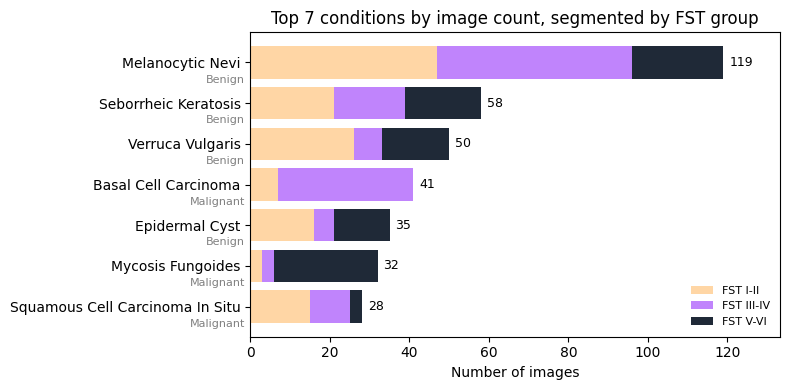

In [2]:
# claude-assisted: top 7 conditions, segmented by Fitzpatrick skin tone
from matplotlib.transforms import blended_transform_factory

condition_counts = labels['disease_clean'].value_counts()
condition_to_malignant = labels.groupby('disease_clean')['malignant'].first()

print(f"Top 7 conditions by image count:")
print(condition_counts.head(7))
print(f"\nClasses with fewer than 10 images: {(condition_counts < 10).sum()}")
print(f"Classes with 30+ images:           {(condition_counts >= 30).sum()}")

top7 = condition_counts.head(7).sort_values()

fst_groups = [12, 34, 56]
fst_labels = {12: 'FST I-II', 34: 'FST III-IV', 56: 'FST V-VI'}
fst_colors = {12: '#FFD6A5', 34: '#C084FC', 56: '#1F2937'}

fst_counts = (
    labels[labels['disease_clean'].isin(top7.index)]
    .groupby(['disease_clean', 'skin_tone']).size()
    .unstack(fill_value=0)
    .reindex(index=top7.index, columns=fst_groups, fill_value=0)
)

fig, ax = plt.subplots(figsize=(8, 4))
left = [0] * len(top7)
for fst in fst_groups:
    vals = fst_counts[fst].values
    ax.barh(range(len(top7)), vals, left=left, color=fst_colors[fst], label=fst_labels[fst])
    left = [l + v for l, v in zip(left, vals)]

ax.set_yticks(range(len(top7)))
ax.set_yticklabels(top7.index)
ax.set_xlabel('Number of images')
ax.set_ylabel('')
ax.set_title('Top 7 conditions by image count, segmented by FST group')
ax.set_xlim(0, top7.values.max() * 1.12)
ax.legend(loc='lower right', fontsize=8, frameon=False)

for i, val in enumerate(top7.values):
    ax.text(val + 1.5, i, str(val), va='center', ha='left', fontsize=9)

trans = blended_transform_factory(ax.transAxes, ax.transData)
for i, condition in enumerate(top7.index):
    tag = 'Malignant' if condition_to_malignant[condition] else 'Benign'
    ax.text(-0.01, i - 0.42, tag, ha='right', va='center', fontsize=8, color='gray', transform=trans)

plt.tight_layout()
plt.show()

## 2. Pick the top 7 conditions

Filter to the 7 most-frequent conditions and save the list to `data/public/top_conditions.json` so other notebooks can read it. Selection is purely by image volume — no clinical preselection. CLIP downstream will reveal which pairs are visually confusable; whether those match known clinical lookalikes is the *validation* step, not the input.

The second cell sanity-checks that malignancy is constant within each label — that's what justifies a single Malignant/Benign tag per condition (rather than per image).

In [3]:
# claude-assisted: pick top 7 conditions, save to JSON
import json
from pathlib import Path

N_CONDITIONS = 7
TOP_CONDITIONS = condition_counts.head(N_CONDITIONS).index.tolist()

print(f"Top {N_CONDITIONS} conditions selected (by image count):")
for c in TOP_CONDITIONS:
    print(f"  {condition_counts[c]:4d}  {c}")

filtered = labels[labels['disease_clean'].isin(TOP_CONDITIONS)]
print(f"\nFiltered dataset: {len(filtered)} images across {N_CONDITIONS} conditions")
print(f"(down from {len(labels)} images across {labels['disease_clean'].nunique()} conditions)")

output_path = Path('../data/public/top_conditions.json')
output_path.parent.mkdir(parents=True, exist_ok=True)
with output_path.open('w') as f:
    json.dump(TOP_CONDITIONS, f, indent=2)
print(f"\nSaved condition list to {output_path}")

Top 7 conditions selected (by image count):
   119  Melanocytic Nevi
    58  Seborrheic Keratosis
    50  Verruca Vulgaris
    41  Basal Cell Carcinoma
    35  Epidermal Cyst
    32  Mycosis Fungoides
    28  Squamous Cell Carcinoma In Situ

Filtered dataset: 363 images across 7 conditions
(down from 363 images across 7 conditions)

Saved condition list to ../data/public/top_conditions.json


In [4]:
# claude-assisted: confirm malignancy is consistent within each top-7 label
malignancy_check = (
    labels[labels['disease_clean'].isin(TOP_CONDITIONS)]
    .groupby('disease_clean')['malignant']
    .agg(['unique', 'count'])
    .rename(columns={'unique': 'malignant_values', 'count': 'image_count'})
)
malignancy_check['is_consistent'] = malignancy_check['malignant_values'].apply(lambda v: len(v) == 1)
malignancy_check

,malignant_values,image_count,is_consistent
disease_clean,,,
Basal Cell Carcinoma,[True],41,True
Epidermal Cyst,[False],35,True
Melanocytic Nevi,[False],119,True
Mycosis Fungoides,[True],32,True
Seborrheic Keratosis,[False],58,True
Squamous Cell Carcinoma In Situ,[True],28,True
Verruca Vulgaris,[False],50,True


## 3. Sample image grid

One image per chosen condition. First visual look at what the model is asked to distinguish.

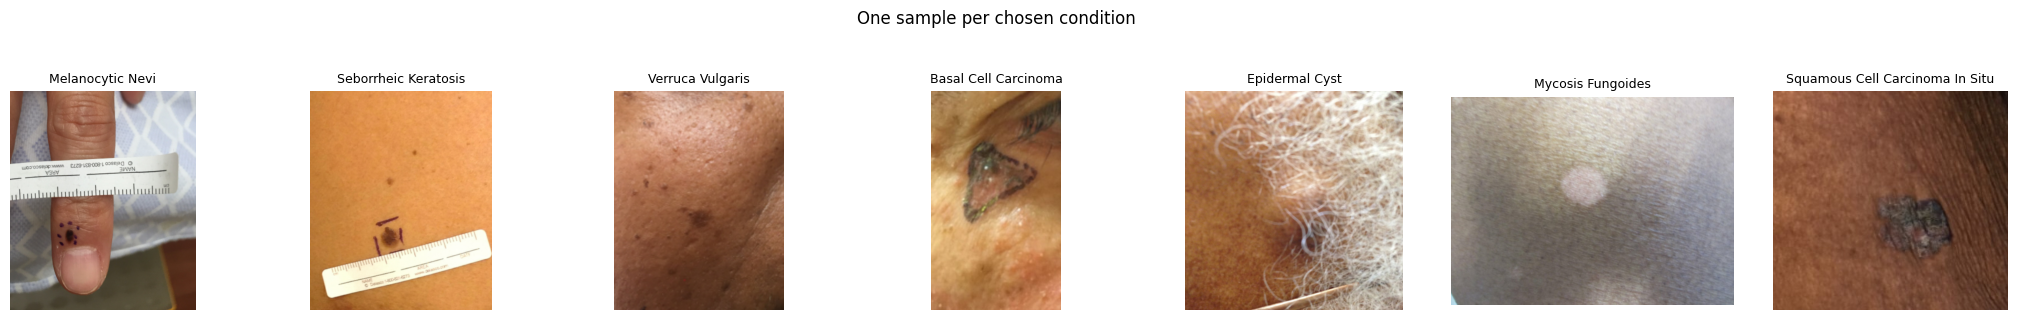

In [5]:
# claude-assisted: sample image grid
import os
from PIL import Image

IMAGE_DIR = '../data/private/images'

fig, axes = plt.subplots(1, len(TOP_CONDITIONS), figsize=(3 * len(TOP_CONDITIONS), 3))
for ax, condition in zip(axes, TOP_CONDITIONS):
    sample_row = labels[labels['disease_clean'] == condition].iloc[0]
    img = Image.open(os.path.join(IMAGE_DIR, sample_row['DDI_file'])).convert('RGB')
    ax.imshow(img)
    ax.set_title(condition, fontsize=9, wrap=True)
    ax.axis('off')

plt.suptitle('One sample per chosen condition', y=1.05, fontsize=12)
plt.tight_layout()
plt.show()

## Summary

- **Heavy class imbalance** in DDI — long tail of rare conditions, a few common ones with 30+ images. This justifies filtering to a top-N subset rather than retrieving over all 78 conditions.
- **Filtered to top 7 conditions by volume** (363 images), no clinical preselection bias.
- **All three FST groups represented** in the subset — but unevenly across conditions (visible in the segmented chart). Some conditions skew heavily toward one FST group; this surfaces as per-condition data gaps in the app's home view.
- **Malignancy is consistent within each top-7 label** — verified — supporting one M/B tag per condition.
- **`top_conditions.json` saved** at `data/public/top_conditions.json` for downstream notebooks.

**Next steps:**
- `03_visual_similarity.ipynb`: filter to TOP_CONDITIONS before embedding, then compute CLIP-derived distractors per condition.
- `04_build_explanations.ipynb`: precache RAG-grounded explanations per (correct, distractor) pair.